# False Positive Reduction using Random Forest Confidence Scoring

This notebook applies a **Random Forest model** as a confidence-based filtering layer
to reduce false positives in web vulnerability scanner outputs.

**Key idea:** ML is used to assign FP likelihood scores, not hard classifications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

## Load Cleaned Dataset

In [2]:
df = pd.read_csv("dataset_without_duplicates.csv")
print("Total rows:", len(df))
df.head()

Total rows: 108993


,name,severity,project_name,url,parameter,evidence,cwe_id,has_evidence
0,missing_security_header,medium,infinity waves solution,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0
1,missing_security_header,medium,DemoCorp,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0
2,information_disclosure,low,DemoCorp,https://example.com/,Not Applicable,"{'type': 'Error messages or stack traces', 'co...",Not Applicable,1
3,Missing Anti-clickjacking Header,medium,DemoCorp,https://example.com,x-frame-options,Not Applicable,Not Applicable,0
4,Content Security Policy (CSP) Header Not Set,medium,DemoCorp,https://example.com,Not Applicable,Not Applicable,Not Applicable,0


## Feature Engineering

In [3]:
df["name_norm"] = df["name"].str.lower().str.strip()
df["project_name_norm"] = df["project_name"].str.lower().str.strip()

df.head()

,name,severity,project_name,url,parameter,evidence,cwe_id,has_evidence,name_norm,project_name_norm
0,missing_security_header,medium,infinity waves solution,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,infinity waves solution
1,missing_security_header,medium,DemoCorp,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,ranchers
2,information_disclosure,low,DemoCorp,https://example.com/,Not Applicable,"{'type': 'Error messages or stack traces', 'co...",Not Applicable,1,information_disclosure,ranchers
3,Missing Anti-clickjacking Header,medium,DemoCorp,https://example.com,x-frame-options,Not Applicable,Not Applicable,0,missing anti-clickjacking header,ranchers
4,Content Security Policy (CSP) Header Not Set,medium,DemoCorp,https://example.com,Not Applicable,Not Applicable,Not Applicable,0,content security policy (csp) header not set,ranchers


In [4]:
header_vulns = [
    "missing_security_header",
    "missing anti-clickjacking header",
    "content security policy (csp) header not set",
    "missing content-security-policy header",
    "strict-transport-security header not set",
    "strict-transport-security missing max-age (non-compliant with spec)",
    "missing hsts header",
    "x-content-type-options header missing",
    "missing x-content-type-options header",
    "missing x-frame-options header",
    "multiple x-frame-options header entries",
    "missing x-xss-protection header",
    "missing referrer-policy header",
    "x-aspnet-version response header",
    "server leaks information via \"x-powered-by\" http response header field(s)",
    "server leaks version information via \"server\" http response header field",
    "permissive cors policy",
    "csp: notices",
    "csp: wildcard directive",
    "csp: style-src unsafe-inline",
    "csp: script-src unsafe-inline",
    "csp: script-src unsafe-eval",
    "csp: failure to define directive with no fallback"
]

df["is_header_issue"] = df["name_norm"].isin(header_vulns).astype(int)

In [5]:
injection_vulns = [
    "sql injection",
    "sql injection - mysql",
    "sql injection - mysql (time based)",
    "sql injection - sqlite (time based)",
    "sql injection - mssql (time based)",
    "cross site scripting (reflected)",
    "cross site scripting (dom based)",
    "cross site scripting (persistent)",
    "xslt injection",
    "format string error",
    "session id in url rewrite"
]

df["is_injection"] = df["name_norm"].isin(injection_vulns).astype(int)

## Identify Real-world Applications

In [6]:
vulnerable_apps = {
    "owasp juice shop",
    "owasp juice shop - e-commerce vulnerabilities",
    "bwapp",
    "bwapp (buggy web application)",
    "dvwa",
    "local dvwa",
    "dvwa sqli",
    "sql injection test project",
    "vulnerable app",
    "demo",
    "portswigger web security academy labs",
    "google's xss testing ground",
    "google gruyere – vulnerable app",
    "ibm banking app vulnerabilities",
    "ibm banking app vulnerabilities (testfire)",
    "classic web vulnerabilities",
    "classic web vulnerabilities (testphp)"
}

df["is_real_world"] = (~df["project_name_norm"].isin(vulnerable_apps)).astype(int)

In [7]:
df.head()
df.to_csv('dataset_after_feature_engineering.csv', index=False)
df.head()

,name,severity,project_name,url,parameter,evidence,cwe_id,has_evidence,name_norm,project_name_norm,is_header_issue,is_injection,is_real_world
0,missing_security_header,medium,infinity waves solution,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,infinity waves solution,1,0,1
1,missing_security_header,medium,DemoCorp,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,ranchers,1,0,1
2,information_disclosure,low,DemoCorp,https://example.com/,Not Applicable,"{'type': 'Error messages or stack traces', 'co...",Not Applicable,1,information_disclosure,ranchers,0,0,1
3,Missing Anti-clickjacking Header,medium,DemoCorp,https://example.com,x-frame-options,Not Applicable,Not Applicable,0,missing anti-clickjacking header,ranchers,1,0,1
4,Content Security Policy (CSP) Header Not Set,medium,DemoCorp,https://example.com,Not Applicable,Not Applicable,Not Applicable,0,content security policy (csp) header not set,ranchers,1,0,1


## Pseudo-labeling (Weak Supervision)

In [8]:
df["likely_fp"] = 0

df.loc[
    (df["is_real_world"] == 1) &
    (df["is_header_issue"] == 1) &
    (df["has_evidence"] == 0) &
    (df["severity"].isin(["low", "medium"])),
    "likely_fp"
] = 1

df["likely_fp"].value_counts(normalize=True)

likely_fp
0    0.74513
1    0.25487
Name: proportion, dtype: float64

In [9]:
df.head()

,name,severity,project_name,url,parameter,evidence,cwe_id,has_evidence,name_norm,project_name_norm,is_header_issue,is_injection,is_real_world,likely_fp
0,missing_security_header,medium,infinity waves solution,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,infinity waves solution,1,0,1,1
1,missing_security_header,medium,DemoCorp,https://example.com/,Not Applicable,Not Applicable,Not Applicable,0,missing_security_header,ranchers,1,0,1,1
2,information_disclosure,low,DemoCorp,https://example.com/,Not Applicable,"{'type': 'Error messages or stack traces', 'co...",Not Applicable,1,information_disclosure,ranchers,0,0,1,0
3,Missing Anti-clickjacking Header,medium,DemoCorp,https://example.com,x-frame-options,Not Applicable,Not Applicable,0,missing anti-clickjacking header,ranchers,1,0,1,1
4,Content Security Policy (CSP) Header Not Set,medium,DemoCorp,https://example.com,Not Applicable,Not Applicable,Not Applicable,0,content security policy (csp) header not set,ranchers,1,0,1,1


## Random Forest as FP Confidence Model

In [10]:
real_df = df[df["is_real_world"] == 1]

features = [
    "has_evidence",
    "is_header_issue",
    "is_injection"
]

X = real_df[features]
y = real_df["likely_fp"]

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## False Positive Confidence Scores

In [11]:
real_df["fp_confidence"] = rf.predict_proba(X)[:, 1]
real_df[["name", "severity", "fp_confidence"]].head()

/tmp/ipykernel_19864/3939618714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df["fp_confidence"] = rf.predict_proba(X)[:, 1]


,name,severity,fp_confidence
0,missing_security_header,medium,1.0
1,missing_security_header,medium,1.0
2,information_disclosure,low,0.0
3,Missing Anti-clickjacking Header,medium,1.0
4,Content Security Policy (CSP) Header Not Set,medium,1.0


## Confidence Distribution

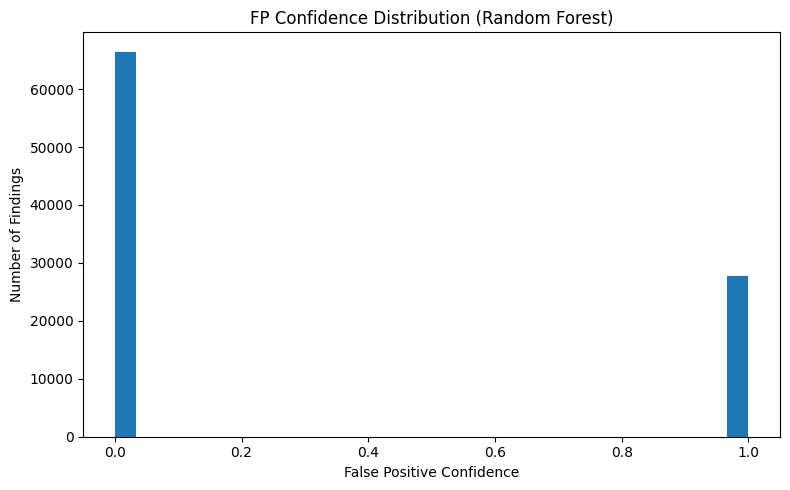

/home/hannan-ali/Dataset/fp_confidence_distribution_rf.png

In [23]:
import matplotlib.pyplot as plt
from IPython.display import FileLink

plt.figure(figsize=(8, 5))
plt.hist(real_df["fp_confidence"], bins=30)
plt.xlabel("False Positive Confidence")
plt.ylabel("Number of Findings")
plt.title("FP Confidence Distribution (Random Forest)")
plt.tight_layout()

# Save figure
plt.savefig("fp_confidence_distribution_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Download link
FileLink("fp_confidence_distribution_rf.png")


## Threshold-based Filtering

In [13]:
threshold = 0.7

real_df["fp_filtered"] = (real_df["fp_confidence"] >= threshold).astype(int)

total_alerts = len(real_df)
filtered_alerts = real_df["fp_filtered"].sum()

print(f"Total alerts: {total_alerts}")
print(f"Filtered as likely FP: {filtered_alerts}")
print(f"FP Reduction: {(filtered_alerts / total_alerts) * 100:.2f}%")

Total alerts: 94256
Filtered as likely FP: 27779
FP Reduction: 29.47%


/tmp/ipykernel_19864/2346815878.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df["fp_filtered"] = (real_df["fp_confidence"] >= threshold).astype(int)


## Threshold Sensitivity Analysis

In [14]:
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    filtered = (real_df["fp_confidence"] >= t).sum()
    print(f"Threshold {t}: {filtered} alerts filtered ({(filtered/total_alerts)*100:.2f}%)")

Threshold 0.5: 27779 alerts filtered (29.47%)
Threshold 0.6: 27779 alerts filtered (29.47%)
Threshold 0.7: 27779 alerts filtered (29.47%)
Threshold 0.8: 27779 alerts filtered (29.47%)
Threshold 0.9: 27779 alerts filtered (29.47%)


In [14]:
import joblib

joblib.dump(rf, "fp_confidence_random_forest.pkl")

print("✅ Model saved successfully")


✅ Model saved successfully


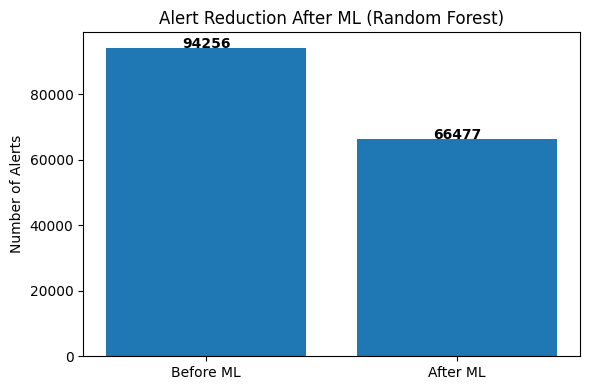

/home/hannan-ali/Dataset/alert_reduction_rf.png

In [24]:
before_count = len(real_df)
after_count = len(real_df[real_df["fp_filtered"] == 0])

plt.figure(figsize=(6,4))
plt.bar(["Before ML", "After ML"], [before_count, after_count])
plt.ylabel("Number of Alerts")
plt.title("Alert Reduction After ML (Random Forest)")

for i, v in enumerate([before_count, after_count]):
    plt.text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()

# Save figure
plt.savefig("alert_reduction_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Download link
FileLink("alert_reduction_rf.png")


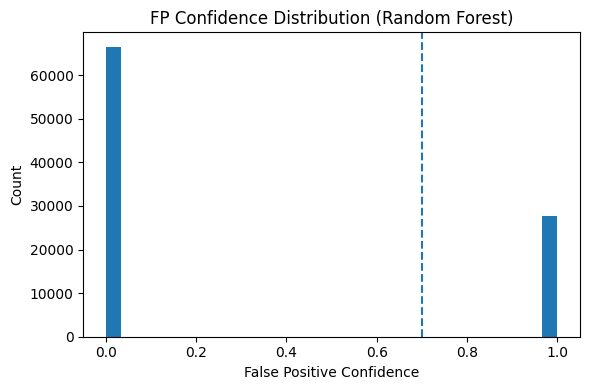

In [17]:
plt.figure(figsize=(6,4))
plt.hist(real_df["fp_confidence"], bins=30)
plt.axvline(threshold, linestyle="--")
plt.xlabel("False Positive Confidence")
plt.ylabel("Count")
plt.title("FP Confidence Distribution (Random Forest)")
plt.tight_layout()
plt.show()


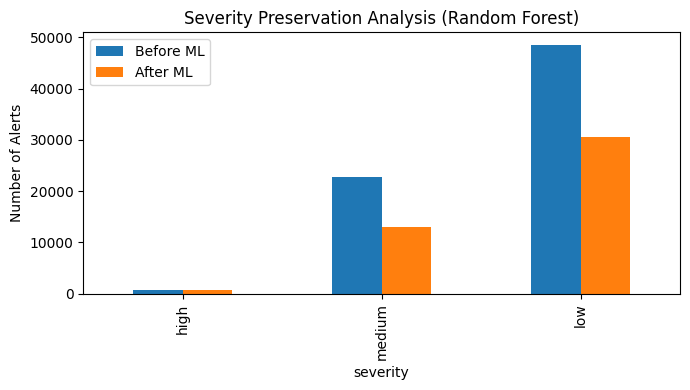

/home/hannan-ali/Dataset/severity_preservation_rf.png

In [25]:
severity_before = real_df["severity"].value_counts()
severity_after = real_df[real_df["fp_filtered"] == 0]["severity"].value_counts()

severity_df = (
    pd.DataFrame({
        "Before ML": severity_before,
        "After ML": severity_after
    })
    .fillna(0)
)

severity_df = severity_df.reindex(["high", "medium", "low"])

severity_df.plot(kind="bar", figsize=(7,4))
plt.ylabel("Number of Alerts")
plt.title("Severity Preservation Analysis (Random Forest)")
plt.tight_layout()

# Save figure
plt.savefig("severity_preservation_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Download link
FileLink("severity_preservation_rf.png")


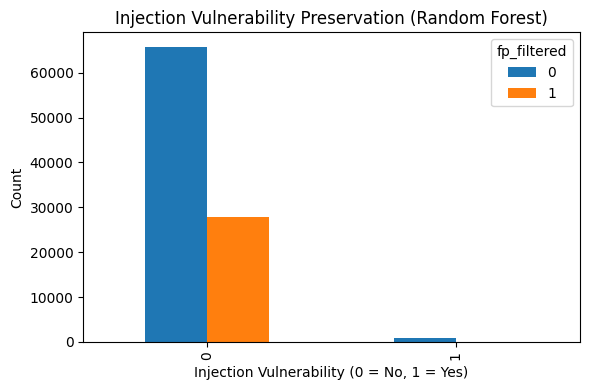

In [19]:
inj_stats = pd.crosstab(
    real_df["is_injection"],
    real_df["fp_filtered"]
)

inj_stats.plot(kind="bar", figsize=(6,4))
plt.xlabel("Injection Vulnerability (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Injection Vulnerability Preservation (Random Forest)")
plt.tight_layout()
plt.show()


In [21]:
from IPython.display import display, HTML

def display_with_scroll(df, title="", height=400):
    display(HTML(f"<h4>{title}</h4>"))
    display(HTML(
        f"<div style='max-height:{height}px; overflow:auto; border:1px solid #ccc;'>"
        f"{df.to_html(index=False)}"
        f"</div>"
    ))


In [22]:
before_df = real_df
after_df = real_df[real_df["fp_filtered"] == 0]

comparison_df = pd.DataFrame({
    "Before ML": before_df["name"].value_counts(),
    "After ML": after_df["name"].value_counts()
}).fillna(0).astype(int)

display_with_scroll(
    comparison_df.reset_index().rename(columns={"index": "Vulnerability Name"}),
    title="Before vs After ML – Vulnerability Counts (Random Forest)",
    height=400
)


name,Before ML,After ML
Absence of Anti-CSRF Tokens,3857,3857
Application Error Disclosure,46,46
Authentication Request Identified,32,32
Big Redirect Detected (Potential Sensitive Information Leak),62,62
CSP: Failure to Define Directive with No Fallback,1353,1353
CSP: Header & Meta,1,1
CSP: Notices,19,19
CSP: Wildcard Directive,1311,1311
CSP: X-Content-Security-Policy,1,1
CSP: script-src unsafe-eval,25,25
